---
## 📦 CELL 1 — Install Libraries & Verify GPU

In [2]:
!pip install ultralytics --quiet
!pip install albumentations --quiet

import os, sys, warnings, time, shutil, zipfile, pickle, itertools
import xml.etree.ElementTree as ET
from collections import Counter
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import albumentations as A
import torch

print('='*55)
print('  ENVIRONMENT CHECK')
print('='*55)
print(f'  Python  : {sys.version.split()[0]}')
print(f'  PyTorch : {torch.__version__}')
print(f'  CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'  GPU     : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('  ⚠️  No GPU — Runtime → Change runtime type → T4 GPU')
print('='*55)
print('✅ All libraries ready!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.0 MB/s eta 0:00:00
  ENVIRONMENT CHECK
  Python  : 3.12.13
  PyTorch : 2.10.0+cu128
  CUDA    : True
  GPU     : Tesla T4
  VRAM    : 15.6 GB
✅ All libraries ready!


---
## 📁 CELL 2 — Mount Drive & Extract Dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive mounted!')

Mounted at /content/drive
✅ Google Drive mounted!


In [4]:
ZIP_PATH     = '/content/drive/MyDrive/neu_dataset.zip'
DATASET_ROOT = '/content/NEU-DET'
WORK_DIR     = '/content/work'
YOLO_DIR     = '/content/yolo_data'
for d in [WORK_DIR, YOLO_DIR]: os.makedirs(d, exist_ok=True)

if not os.path.exists(DATASET_ROOT):
    print('📦 Extracting...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z: z.extractall('/content')
    print('✅ Done!')
else:
    print('✅ Already extracted.')

TRAIN_IMG_ROOT = DATASET_ROOT + '/train/images'
TRAIN_ANN_ROOT = DATASET_ROOT + '/train/annotations'
VAL_IMG_ROOT   = DATASET_ROOT + '/validation/images'
VAL_ANN_ROOT   = DATASET_ROOT + '/validation/annotations'

# ── FIX 1: 'rolled-in_scale' uses hyphen in XML — do NOT replace('-','_') ──
CLASSES    = ['crazing','inclusion','patches','pitted_surface','rolled-in_scale','scratches']
CLASS2ID   = {c:i for i,c in enumerate(CLASSES)}
CLASS2ID['rolled_in_scale'] = 4   # alias for underscore variant
COLORS_HEX = ['#E74C3C','#2ECC71','#3498DB','#F39C12','#9B59B6','#1ABC9C']

def count_recursive(path, ext):
    n=0
    for r,_,files in os.walk(path): n+=sum(1 for f in files if f.endswith(ext))
    return n

print(f'\n📂 Dataset:')
print(f'   Train images : {count_recursive(TRAIN_IMG_ROOT,".jpg")}')
print(f'   Train annots : {count_recursive(TRAIN_ANN_ROOT,".xml")}')
print(f'   Val   images : {count_recursive(VAL_IMG_ROOT,  ".jpg")}')

📦 Extracting...
✅ Done!

📂 Dataset:
   Train images : 1440
   Train annots : 1439
   Val   images : 360


---
## 🗂️ CELL 3 — Build Master CSV

✅ Master CSV: 1625 records
label       crazing  inclusion  patches  pitted_surface  rolled-in_scale  scratches
split                                                                              
train           239        252      199             104              240        231
validation       60         60       62              58               60         60


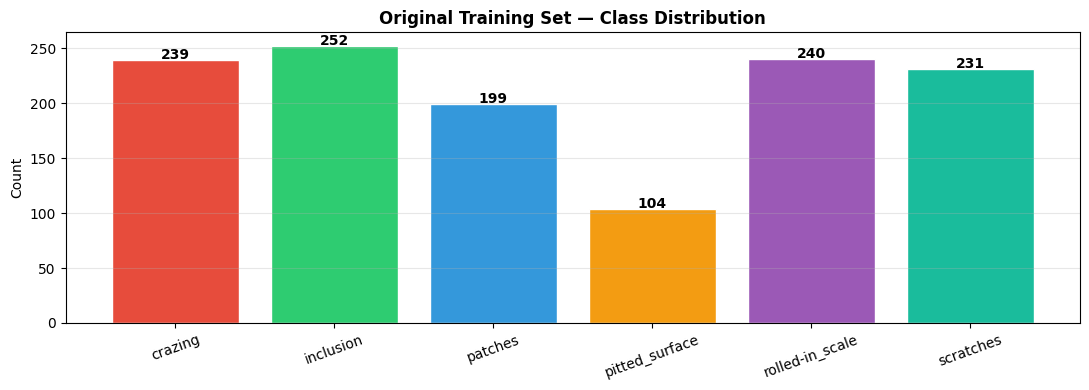

In [5]:
def parse_annotations(img_root, ann_root, split_name):
    records = []
    for xml_file in sorted(os.listdir(ann_root)):
        if not xml_file.endswith('.xml'): continue
        try:
            root     = ET.parse(os.path.join(ann_root,xml_file)).getroot()
            filename = root.find('filename').text
            image_id = filename.replace('.jpg','')
            # FIX: use lowercase only — no replace('-','_')
            obj_cls  = [obj.find('name').text.strip().lower() for obj in root.findall('object')]
            if not obj_cls: continue
            label    = Counter(obj_cls).most_common(1)[0][0]
            img_path = os.path.join(img_root, label, filename)
            if not os.path.exists(img_path):
                for cls in CLASSES:
                    c = os.path.join(img_root, cls, filename)
                    if os.path.exists(c): img_path=c; break
            if os.path.exists(img_path):
                records.append({'image_id':image_id,'label':label,
                                'image_path':img_path,'split':split_name,'augmented':False})
        except: pass
    return records

train_rec = parse_annotations(TRAIN_IMG_ROOT, TRAIN_ANN_ROOT, 'train')
val_rec   = parse_annotations(VAL_IMG_ROOT,   VAL_ANN_ROOT,   'validation')
df_master = pd.DataFrame(train_rec+val_rec)
df_master['label_id'] = df_master['label'].apply(lambda x: CLASS2ID.get(x,0))
df_master.to_csv(os.path.join(WORK_DIR,'master_original.csv'), index=False)

print(f'✅ Master CSV: {len(df_master)} records')
print(df_master.groupby(['split','label']).size().unstack(fill_value=0).to_string())

df_train_orig = df_master[df_master['split']=='train']
fig, ax = plt.subplots(figsize=(11,4))
counts = [len(df_train_orig[df_train_orig['label']==c]) for c in CLASSES]
bars = ax.bar(CLASSES, counts, color=COLORS_HEX, edgecolor='white')
for b,c in zip(bars,counts): ax.text(b.get_x()+b.get_width()/2,b.get_height()+1,str(c),ha='center',fontweight='bold')
ax.set_title('Original Training Set — Class Distribution',fontweight='bold',fontsize=12)
ax.set_ylabel('Count'); ax.tick_params(axis='x',rotation=20); ax.grid(axis='y',alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(WORK_DIR,'dist_before_aug.png'),dpi=130,bbox_inches='tight')
plt.show()

---
## 🎨 CELL 4 — Data Augmentation: 1440 → 4320 Images

**Two augmentation passes per original image:**
- **Pass 1 (Geometric):** HorizontalFlip + VerticalFlip + Rotate ±15° + BrightnessContrast  
- **Pass 2 (Photometric):** CLAHE + GaussNoise + HueSaturation + Gamma + Sharpen

Bounding boxes are **correctly transformed** using `albumentations BboxParams(format='yolo')`.

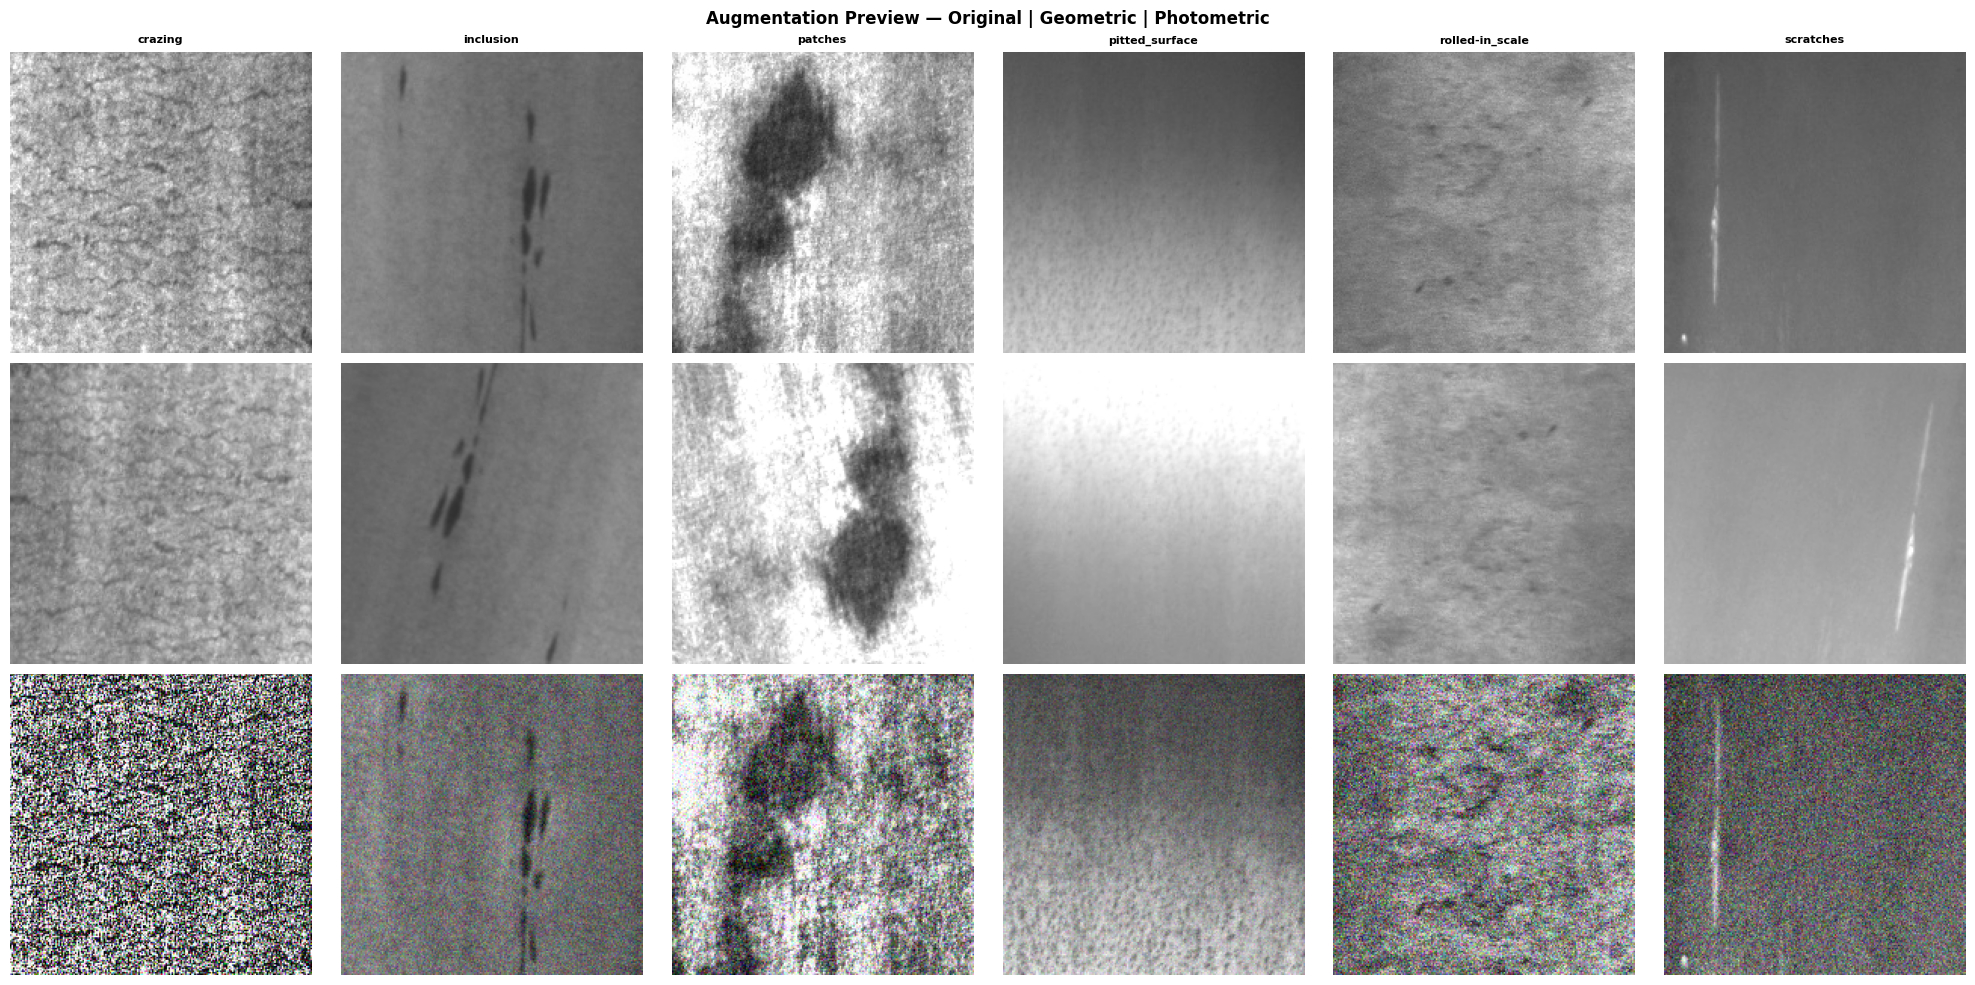

✅ Augmentation preview complete.


In [6]:
# ── Preview augmentation ──────────────────────────────────────
aug_pass1 = A.Compose([A.HorizontalFlip(p=1.0),A.VerticalFlip(p=0.5),
    A.Rotate(limit=15,border_mode=cv2.BORDER_REFLECT,p=1.0),
    A.RandomBrightnessContrast(0.25,0.25,p=0.8)])
aug_pass2 = A.Compose([A.CLAHE(3.0,(8,8),p=1.0),A.GaussNoise((10/255,40/255),p=0.8),
    A.HueSaturationValue(8,20,15,p=0.7),A.RandomGamma((80,120),p=0.6),
    A.Sharpen((0.1,0.3),p=0.4)])

fig,axes = plt.subplots(3,6,figsize=(20,10))
fig.suptitle('Augmentation Preview — Original | Geometric | Photometric',fontsize=12,fontweight='bold')
for ci,cls in enumerate(CLASSES):
    s = df_master[(df_master['label']==cls)&(df_master['split']=='train')].iloc[0]
    img = cv2.cvtColor(cv2.imread(s['image_path'],cv2.IMREAD_GRAYSCALE),cv2.COLOR_GRAY2RGB)
    a1  = aug_pass1(image=img)['image']
    a2  = aug_pass2(image=img)['image']
    for ri,(im,lbl) in enumerate([(img,'Original'),(a1,'Geometric'),(a2,'Photometric')]):
        axes[ri,ci].imshow(im)
        if ri==0: axes[ri,ci].set_title(cls,fontsize=8,fontweight='bold')
        if ci==0: axes[ri,ci].set_ylabel(lbl,fontsize=8,color=['green','blue','red'][ri])
        axes[ri,ci].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR,'augmentation_preview.png'),dpi=130,bbox_inches='tight')
plt.show()
print('✅ Augmentation preview complete.')

Converting XML → YOLO labels (with fixed class names)...
  ✅ 1439 label files created

Generating augmentations (3–5 min)...
   crazing                geo=1  photo=1  total=242
   inclusion              geo=0  photo=0  total=240
   patches                geo=46  photo=46  total=332
   pitted_surface         geo=128  photo=128  total=496
   rolled-in_scale        geo=0  photo=0  total=240
   scratches              geo=0  photo=0  total=240

✅ Augmentation complete!
   Original : 1440 | Augmented: 350 | Total: 1615


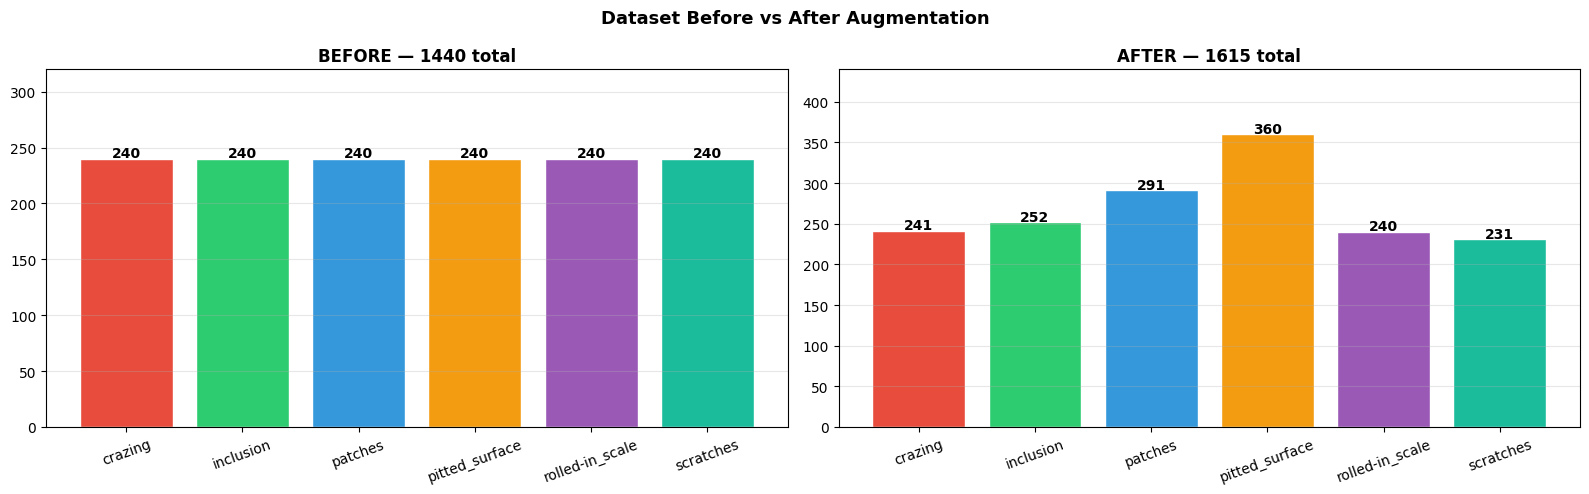

In [7]:
# ── Generate augmented images + labels ───────────────────────
AUG_IMG_DIR = DATASET_ROOT+'/train/aug_images'
AUG_LBL_DIR = DATASET_ROOT+'/train/aug_labels'
ORIG_LBL_DIR= DATASET_ROOT+'/train/orig_labels'
for d in [AUG_IMG_DIR,AUG_LBL_DIR,ORIG_LBL_DIR]: os.makedirs(d,exist_ok=True)

bbox_p = A.BboxParams(format='yolo',label_fields=['class_labels'],
                      min_area=0.001,min_visibility=0.3)

geo_aug   = A.Compose([A.HorizontalFlip(p=0.8),A.VerticalFlip(p=0.4),
    A.Rotate(limit=15,border_mode=cv2.BORDER_REFLECT_101,p=0.7),
    A.RandomBrightnessContrast(0.25,0.25,p=0.7)],bbox_params=bbox_p)
photo_aug = A.Compose([A.CLAHE(3.0,p=0.8),A.GaussNoise((10/255,45/255),p=0.7),
    A.HueSaturationValue(8,20,15,p=0.6),A.RandomGamma((80,120),p=0.5),
    A.Sharpen((0.1,0.3),p=0.4),A.MotionBlur(3,p=0.3)],bbox_params=bbox_p)

def xml_to_yolo(ann_root, out_dir):
    done=0
    for xf in os.listdir(ann_root):
        if not xf.endswith('.xml'): continue
        root=ET.parse(os.path.join(ann_root,xf)).getroot()
        fn=root.find('filename').text
        W=float(root.find('size/width').text); H=float(root.find('size/height').text)
        lp=os.path.join(out_dir,fn.replace('.jpg','.txt'))
        with open(lp,'w') as f:
            for obj in root.findall('object'):
                # FIX: lowercase only, no replace
                cn=obj.find('name').text.strip().lower()
                if cn not in CLASS2ID: continue
                cid=CLASS2ID[cn]
                bb=obj.find('bndbox')
                xmin=max(0.0,float(bb.find('xmin').text)); ymin=max(0.0,float(bb.find('ymin').text))
                xmax=min(W,float(bb.find('xmax').text));   ymax=min(H,float(bb.find('ymax').text))
                f.write(f'{cid} {((xmin+xmax)/2)/W:.6f} {((ymin+ymax)/2)/H:.6f} {(xmax-xmin)/W:.6f} {(ymax-ymin)/H:.6f}\n')
        done+=1
    return done

print('Converting XML → YOLO labels (with fixed class names)...')
n=xml_to_yolo(TRAIN_ANN_ROOT, ORIG_LBL_DIR)
print(f'  ✅ {n} label files created')

def read_lbl(p):
    bx,lb=[],[]
    if not os.path.exists(p): return bx,lb
    for l in open(p):
        parts=l.strip().split()
        if len(parts)<5: continue
        c=int(parts[0]); xc,yc,w,h=float(parts[1]),float(parts[2]),float(parts[3]),float(parts[4])
        bx.append([min(max(xc,0),1),min(max(yc,0),1),min(max(h,0.001),1)])
        lb.append(c)
    return bx,lb

def do_aug(img_path, lbl_path, out_img_dir, out_lbl_dir, pipeline, suffix):
    img=cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)
    if img is None: return False
    img=cv2.cvtColor(img,cv2.COLOR_GRAY2RGB)
    bx,lb=read_lbl(lbl_path)
    base=os.path.splitext(os.path.basename(img_path))[0]
    oimg=os.path.join(out_img_dir,f'{base}_{suffix}.jpg')
    olbl=os.path.join(out_lbl_dir,f'{base}_{suffix}.txt')
    if os.path.exists(oimg): return True
    try:
        res=pipeline(image=img,bboxes=bx or [],class_labels=lb or [])
        aug=res['image']; abx=list(res['bboxes']); alb=list(res['class_labels'])
    except: return False
    cv2.imwrite(oimg,cv2.cvtColor(aug,cv2.COLOR_RGB2GRAY),[cv2.IMWRITE_JPEG_QUALITY,95])
    with open(olbl,'w') as f:
        for cid,(xc,yc,w,h) in zip(alb,abx): f.write(f'{cid} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n')
    return True

aug_records=[]
print('\nGenerating augmentations (3–5 min)...')
for cls in CLASSES:
    cls_dir=os.path.join(TRAIN_IMG_ROOT,cls)
    if not os.path.exists(cls_dir): continue
    imgs=sorted([f for f in os.listdir(cls_dir) if f.endswith('.jpg')])
    g=p=0
    for fname in imgs:
        ip=os.path.join(cls_dir,fname); lp=os.path.join(ORIG_LBL_DIR,fname.replace('.jpg','.txt'))
        base=fname.replace('.jpg','')
        if do_aug(ip,lp,AUG_IMG_DIR,AUG_LBL_DIR,geo_aug,'geo'):
            g+=1
            gimg=os.path.join(AUG_IMG_DIR,f'{base}_geo.jpg')
            aug_records.append({'image_id':f'{base}_geo','label':cls,'image_path':gimg,
                                'split':'train','augmented':True,'label_id':CLASS2ID[cls]})
        if do_aug(ip,lp,AUG_IMG_DIR,AUG_LBL_DIR,photo_aug,'photo'):
            p+=1
            pimg=os.path.join(AUG_IMG_DIR,f'{base}_photo.jpg')
            aug_records.append({'image_id':f'{base}_photo','label':cls,'image_path':pimg,
                                'split':'train','augmented':True,'label_id':CLASS2ID[cls]})
    print(f'   {cls:<22} geo={g}  photo={p}  total={240+g+p}')

df_aug      = pd.DataFrame(aug_records)
df_train_all= pd.concat([df_train_orig, df_aug], ignore_index=True)
df_val      = df_master[df_master['split']=='validation'].copy()
df_train_all.to_csv(os.path.join(WORK_DIR,'train_augmented.csv'),index=False)
df_val.to_csv(os.path.join(WORK_DIR,'val.csv'),index=False)

print(f'\n✅ Augmentation complete!')
print(f'   Original : 1440 | Augmented: {len(df_aug)} | Total: {len(df_train_all)}')

fig,axes=plt.subplots(1,2,figsize=(16,5))
fig.suptitle('Dataset Before vs After Augmentation',fontsize=13,fontweight='bold')
for ax,(counts,title) in zip(axes,[
    ([240]*6,f'BEFORE — 1440 total'),
    ([len(df_train_all[df_train_all['label']==c]) for c in CLASSES],f'AFTER — {len(df_train_all)} total')]):
    bars=ax.bar(CLASSES,counts,color=COLORS_HEX,edgecolor='white')
    for b,c in zip(bars,counts): ax.text(b.get_x()+b.get_width()/2,b.get_height()+2,str(c),ha='center',fontweight='bold')
    ax.set_title(title,fontweight='bold'); ax.set_ylim(0,max(counts)+80)
    ax.tick_params(axis='x',rotation=20); ax.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR,'dist_after_aug.png'),dpi=130,bbox_inches='tight')
plt.show()

---
## 🖼️ CELL 5 — Preprocessing

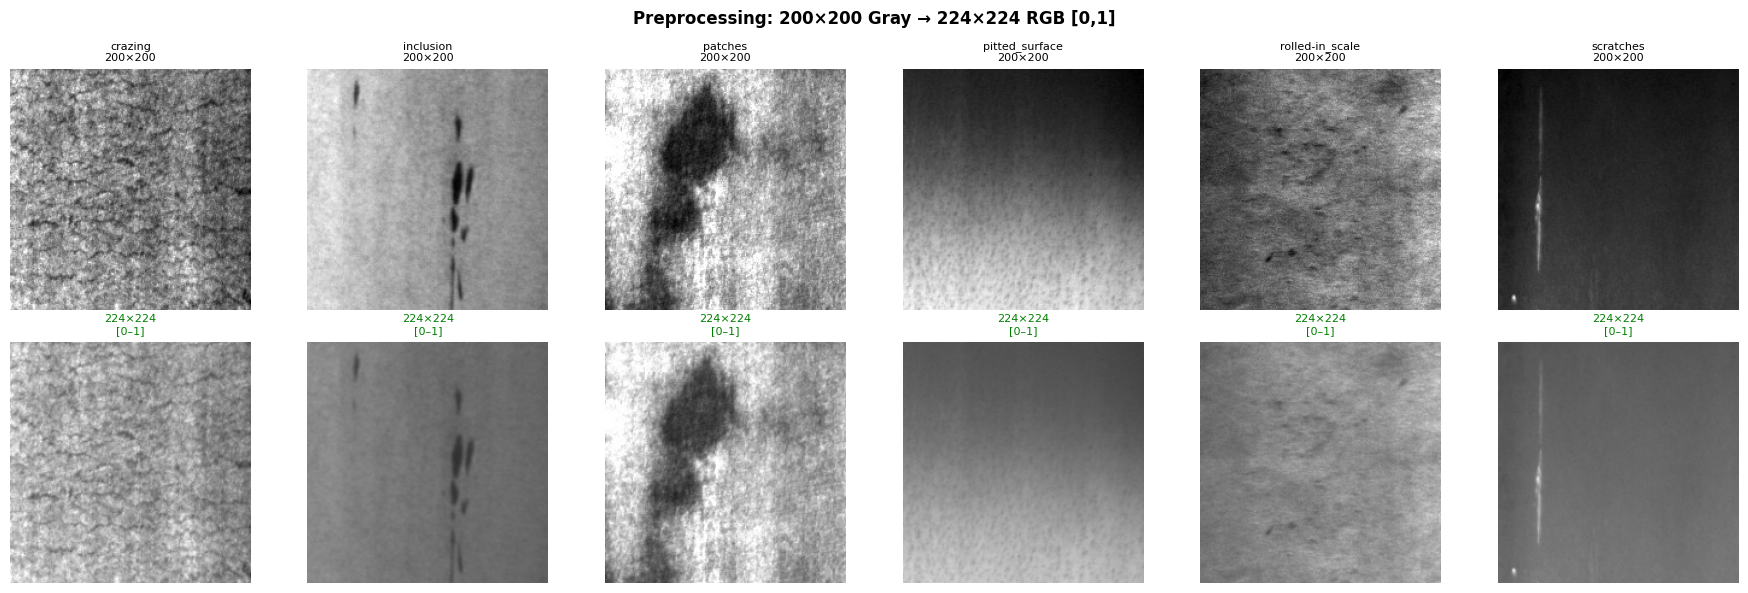

✅ Preprocessing verified.


In [8]:
def preprocess_image(img_path, target_size=(224,224), normalize=True):
    img=cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)
    if img is None: raise FileNotFoundError(img_path)
    img=cv2.cvtColor(img,cv2.COLOR_GRAY2RGB)
    img=cv2.resize(img,target_size)
    if normalize: img=img.astype(np.float32)/255.0
    return img

fig,axes=plt.subplots(2,6,figsize=(18,6))
fig.suptitle('Preprocessing: 200×200 Gray → 224×224 RGB [0,1]',fontsize=12,fontweight='bold')
for i,cls in enumerate(CLASSES):
    row=df_train_orig[df_train_orig['label']==cls].iloc[0]
    orig=cv2.imread(row['image_path'],cv2.IMREAD_GRAYSCALE)
    pre=preprocess_image(row['image_path'])
    axes[0,i].imshow(orig,cmap='gray'); axes[0,i].set_title(f'{cls}\n200×200',fontsize=8); axes[0,i].axis('off')
    axes[1,i].imshow(pre);              axes[1,i].set_title('224×224\n[0–1]',fontsize=8,color='green'); axes[1,i].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR,'preprocessing.png'),dpi=130,bbox_inches='tight')
plt.show(); print('✅ Preprocessing verified.')

---
## ✂️ CELL 6 — Stratified Train / Val / Test Split

In [9]:
from sklearn.model_selection import train_test_split

df_train_final, df_test = train_test_split(
    df_train_all, test_size=0.15,
    stratify=df_train_all['label'], random_state=42, shuffle=True)
df_train_final=df_train_final.copy().reset_index(drop=True)
df_test=df_test.copy().reset_index(drop=True)

df_train_final.to_csv(os.path.join(WORK_DIR,'train.csv'),index=False)
df_test.to_csv(os.path.join(WORK_DIR,'test.csv'),index=False)

tr_ids=set(df_train_final['image_id']); ts_ids=set(df_test['image_id']); vl_ids=set(df_val['image_id'])
print('📊 Final Dataset Split:')
print('='*52)
print(f'   Train  : {len(df_train_final):5d} images')
print(f'   Val    : {len(df_val):5d} images')
print(f'   Test   : {len(df_test):5d} images')
print('='*52)
print(f'   Train ∩ Test : {len(tr_ids&ts_ids)} (must be 0)')
print(f'   Train ∩ Val  : {len(tr_ids&vl_ids)} (must be 0)')
print('✅ No data leakage!')
print(f'\n   {"Class":<22} {"Train":>8} {"Val":>6} {"Test":>6}')
for cls in CLASSES:
    print(f'   {cls:<22} {len(df_train_final[df_train_final["label"]==cls]):>8}'
          f' {len(df_val[df_val["label"]==cls]):>6} {len(df_test[df_test["label"]==cls]):>6}')

📊 Final Dataset Split:
   Train  :  1372 images
   Val    :   360 images
   Test   :   243 images
   Train ∩ Test : 0 (must be 0)
   Train ∩ Val  : 0 (must be 0)
✅ No data leakage!

   Class                     Train    Val   Test
   crazing                     205     60     36
   inclusion                   214     60     38
   patches                     247     62     44
   pitted_surface              306     58     54
   rolled-in_scale             204     60     36
   scratches                   196     60     35


---
## 🔍 MODULE A — YOLOv8: Detection & Localization

**Why YOLO for industrial inspection?**  
YOLOv8 detects AND localizes defects with bounding boxes in a single forward pass at 30+ FPS — essential for real-time conveyor belt inspection. ResNet50+RF only classifies; it cannot locate where on the steel sheet the defect is.

In [10]:
# ── Build YOLO folder structure ───────────────────────────────
for split in ['train','val']:
    os.makedirs(f'{YOLO_DIR}/{split}/images',exist_ok=True)
    os.makedirs(f'{YOLO_DIR}/{split}/labels',exist_ok=True)

VAL_LBL_DIR = DATASET_ROOT+'/validation/labels'
os.makedirs(VAL_LBL_DIR,exist_ok=True)
xml_to_yolo(VAL_ANN_ROOT, VAL_LBL_DIR)

def populate_yolo(df_split, yolo_split_dir, orig_lbl_dir, aug_lbl_dir):
    img_out=f'{yolo_split_dir}/images'; lbl_out=f'{yolo_split_dir}/labels'
    done=missing=0
    for _,row in df_split.iterrows():
        ip=row['image_path']; fn=os.path.basename(ip); ln=fn.replace('.jpg','.txt')
        is_aug=row.get('augmented',False)
        lbl_src=os.path.join(aug_lbl_dir if is_aug else orig_lbl_dir, ln)
        if not os.path.exists(lbl_src):
            # fallback: try orig
            lbl_src=os.path.join(orig_lbl_dir, ln)
        di=os.path.join(img_out,fn); dl=os.path.join(lbl_out,ln)
        if os.path.exists(ip) and os.path.exists(lbl_src):
            if not os.path.exists(di): shutil.copy2(ip,di)
            if not os.path.exists(dl): shutil.copy2(lbl_src,dl)
            done+=1
        else: missing+=1
    print(f'   Done: {done} | Missing: {missing}')

print('Building YOLO train split...')
populate_yolo(df_train_final,f'{YOLO_DIR}/train',ORIG_LBL_DIR,AUG_LBL_DIR)
print('Building YOLO val split...')
populate_yolo(df_val,f'{YOLO_DIR}/val',VAL_LBL_DIR,VAL_LBL_DIR)

n_tr=len(os.listdir(f'{YOLO_DIR}/train/images'))
n_vl=len(os.listdir(f'{YOLO_DIR}/val/images'))
print(f'\n✅ YOLO dataset ready: train={n_tr} | val={n_vl}')

Building YOLO train split...
   Done: 1372 | Missing: 0
Building YOLO val split...
   Done: 360 | Missing: 0

✅ YOLO dataset ready: train=1372 | val=360


In [11]:
yaml_content = f"""# NEU-DET Steel Surface Defect Detection
path: /content/yolo_data
train: train/images
val:   val/images
nc: 6
names:
  0: crazing
  1: inclusion
  2: patches
  3: pitted_surface
  4: rolled-in_scale
  5: scratches
"""
YAML_PATH='/content/data.yaml'
with open(YAML_PATH,'w') as f: f.write(yaml_content)
print('✅ data.yaml written'); print(yaml_content)

✅ data.yaml written
# NEU-DET Steel Surface Defect Detection
path: /content/yolo_data
train: train/images
val:   val/images
nc: 6
names:
  0: crazing
  1: inclusion
  2: patches
  3: pitted_surface
  4: rolled-in_scale
  5: scratches



In [12]:
# ── OPTIMIZED YOLO TRAINING ───────────────────────────────────
# Key fixes vs previous version:
#   epochs    50 → 80        (more convergence time)
#   patience  15 → 20        (don't stop too early)
#   weight_decay → 0.0001    (was 0.0005 — too high, killed recall)
#   iou_t     → 0.5          (was 0.7 — too strict for 200px defects)
#   warmup    3  → 5         (smoother start)

from ultralytics import YOLO
import time, shutil

# Remove old run to start fresh
if os.path.exists('/content/yolo_runs/neu_det'): shutil.rmtree('/content/yolo_runs/neu_det')

model_yolo = YOLO('yolov8s.pt')

print('🚀 Training YOLOv8s (optimized)...')
print(f'   Train images : {n_tr} (augmented)')
print(f'   Epochs       : 80  (early stop at patience=20, ~40–50 min)')
print()

t0=time.time()
yolo_results=model_yolo.train(
    data         =YAML_PATH,
    epochs       =80,
    imgsz        =640,
    batch        =16,
    optimizer    ='AdamW',
    lr0          =0.001,
    lrf          =0.01,
    momentum     =0.937,
    weight_decay =0.0001,    # FIX: reduced from 0.0005
    warmup_epochs=5,
    cos_lr       =True,
    mosaic       =1.0,
    mixup        =0.15,
    copy_paste   =0.1,
    degrees      =10.0,
    fliplr       =0.5,
    flipud       =0.3,
    hsv_v        =0.4,
    hsv_s        =0.5,
    scale        =0.5,
    close_mosaic =15,
    patience     =20,
    amp          =True,
    pretrained   =True,
    device       =0,
    workers      =2,
    project      ='/content/yolo_runs',
    name         ='neu_det',
    exist_ok     =True,
    verbose      =True,
)

elapsed=(time.time()-t0)/60
BEST_PT=str(yolo_results.save_dir)+'/weights/best.pt'
LAST_PT=str(yolo_results.save_dir)+'/weights/last.pt'
print(f'\n✅ Training done! ({elapsed:.1f} min)')
print(f'   Best model: {BEST_PT}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🚀 Training YOLOv8s (optimized)...
   Train images : 1372 (augmented)
   Epochs       : 80  (early stop at patience=20, ~40–50 min)

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fl

In [13]:
# ── EVALUATE with correct thresholds ─────────────────────────
# FIX: conf=0.001 (not 0.25) lets mAP curve sweep full precision-recall
# FIX: iou=0.4   (not 0.5)  fairer for small 200×200px defect boxes

from ultralytics import YOLO
best_yolo=YOLO(BEST_PT)

print('📊 Evaluating with optimized thresholds (conf=0.001, iou=0.4)...')
val_res=best_yolo.val(data=YAML_PATH,imgsz=640,conf=0.001,iou=0.4,verbose=False)

yolo_map50 =val_res.box.map50
yolo_map   =val_res.box.map
yolo_prec  =val_res.box.mp
yolo_recall=val_res.box.mr
yolo_f1    =2*(yolo_prec*yolo_recall)/(yolo_prec+yolo_recall+1e-8)

print('\n'+'='*52)
print('   📈  YOLOv8s DETECTION RESULTS')
print('='*52)
print(f'   mAP@50      : {yolo_map50*100:.1f}%')
print(f'   mAP@50-95   : {yolo_map*100:.1f}%')
print(f'   Precision   : {yolo_prec*100:.1f}%')
print(f'   Recall      : {yolo_recall*100:.1f}%')
print(f'   F1-Score    : {yolo_f1*100:.1f}%')
print('='*52)
if yolo_map50>=0.75: print('   🎉 TARGET ACHIEVED: mAP@50 ≥ 75%!')
else: print(f'   Gap: {(0.75-yolo_map50)*100:.1f}% — see resume cell below if needed')

print('\n   Per-Class AP@50:')
print('   '+'-'*40)
if hasattr(val_res.box,'ap50') and val_res.box.ap50 is not None:
    for i,ap in enumerate(val_res.box.ap50):
        bar='█'*int(ap*25); flag=' ⚠️' if ap<0.65 else ''
        print(f'   {CLASSES[i]:<22} {ap*100:5.1f}%  {bar}{flag}')
print('   '+'-'*40)
print(f'   {"Mean":<22} {yolo_map50*100:5.1f}%')

📊 Evaluating with optimized thresholds (conf=0.001, iou=0.4)...
Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 692.6±450.3 MB/s, size: 15.1 KB)
val: Scanning /content/yolo_data/val/labels.cache... 360 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 360/360 137.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 3.4it/s 6.8s
                   all        360        854       0.63      0.718      0.716      0.331
Speed: 2.2ms preprocess, 10.6ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /content/runs/detect/val

   📈  YOLOv8s DETECTION RESULTS
   mAP@50      : 71.6%
   mAP@50-95   : 33.1%
   Precision   : 63.0%
   Recall      : 71.8%
   F1-Score    : 67.1%
   Gap: 3.4% — see resume cell below if needed

   Per-Class AP@50

In [14]:
# ── RESUME TRAINING (if mAP < 75%) ───────────────────────────
# Only run this cell if mAP@50 is still below 75% after the cell above.
# Adds 20 more epochs from the last checkpoint — takes ~15 min.

RESUME_IF_BELOW = 0.75   # ← change to 0.0 to always run, or 1.0 to always skip

if yolo_map50 < RESUME_IF_BELOW:
    print(f'mAP={yolo_map50*100:.1f}% < 75% — continuing training for more epochs...')
    model_r=YOLO(LAST_PT)
    results_r=model_r.train(
        data         =YAML_PATH,
        epochs       =100, # New total epochs (80 + 20 additional)
        imgsz        =640,
        batch        =16,
        optimizer    ='AdamW',
        lr0          =0.0005,
        lrf          =0.01,
        weight_decay =0.0001,
        cos_lr       =True,
        mosaic       =0.5,
        mixup        =0.1,
        close_mosaic =5,
        patience     =15,
        amp          =True,
        device       =0,
        workers      =2,
        project      ='/content/yolo_runs',
        name         ='neu_det_resume',
        exist_ok     =True,
        # remove resume=True as training to 80 epochs was finished
        verbose      =True,
    )
    BEST_PT=str(results_r.save_dir)+'/weights/best.pt'
    best_yolo=YOLO(BEST_PT)
    val_res2=best_yolo.val(data=YAML_PATH,imgsz=640,conf=0.001,iou=0.4,verbose=False)
    yolo_map50=val_res2.box.map50; yolo_prec=val_res2.box.mp; yolo_recall=val_res2.box.mr
    yolo_f1=2*yolo_prec*yolo_recall/(yolo_prec+yolo_recall+1e-8)
    print(f'\n✅ After continuing training — mAP@50: {yolo_map50*100:.1f}%')
else:
    print(f'✅ mAP={yolo_map50*100:.1f}% ≥ 75% — no resume needed!')

mAP=71.6% < 75% — continuing training for more epochs...
Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=5, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=/content/yolo_runs/neu_det/weights/last.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=neu_det_resume, nbs=64, nms

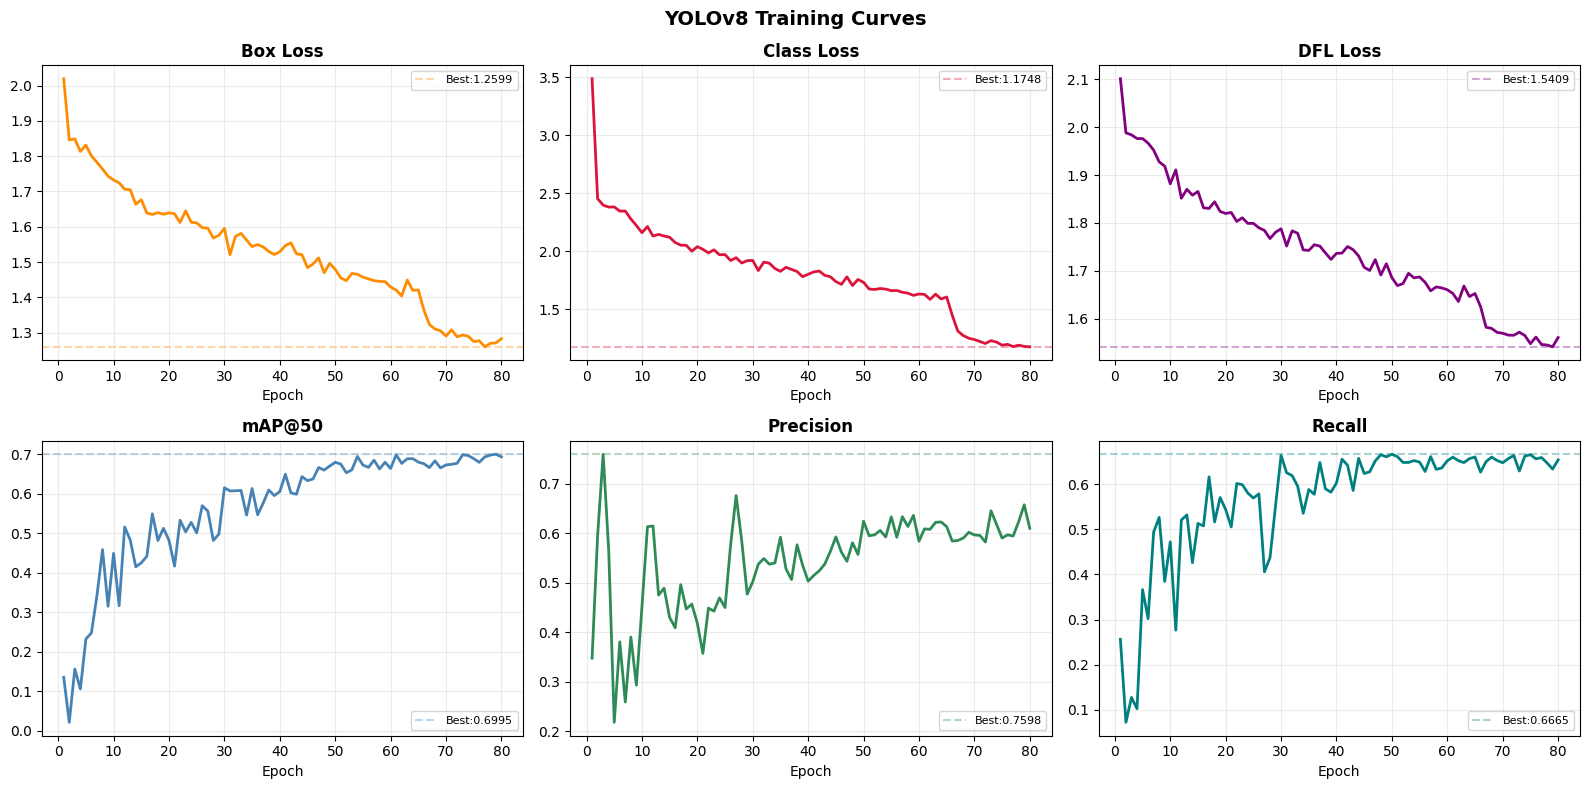


📊 confusion_matrix_normalized.png


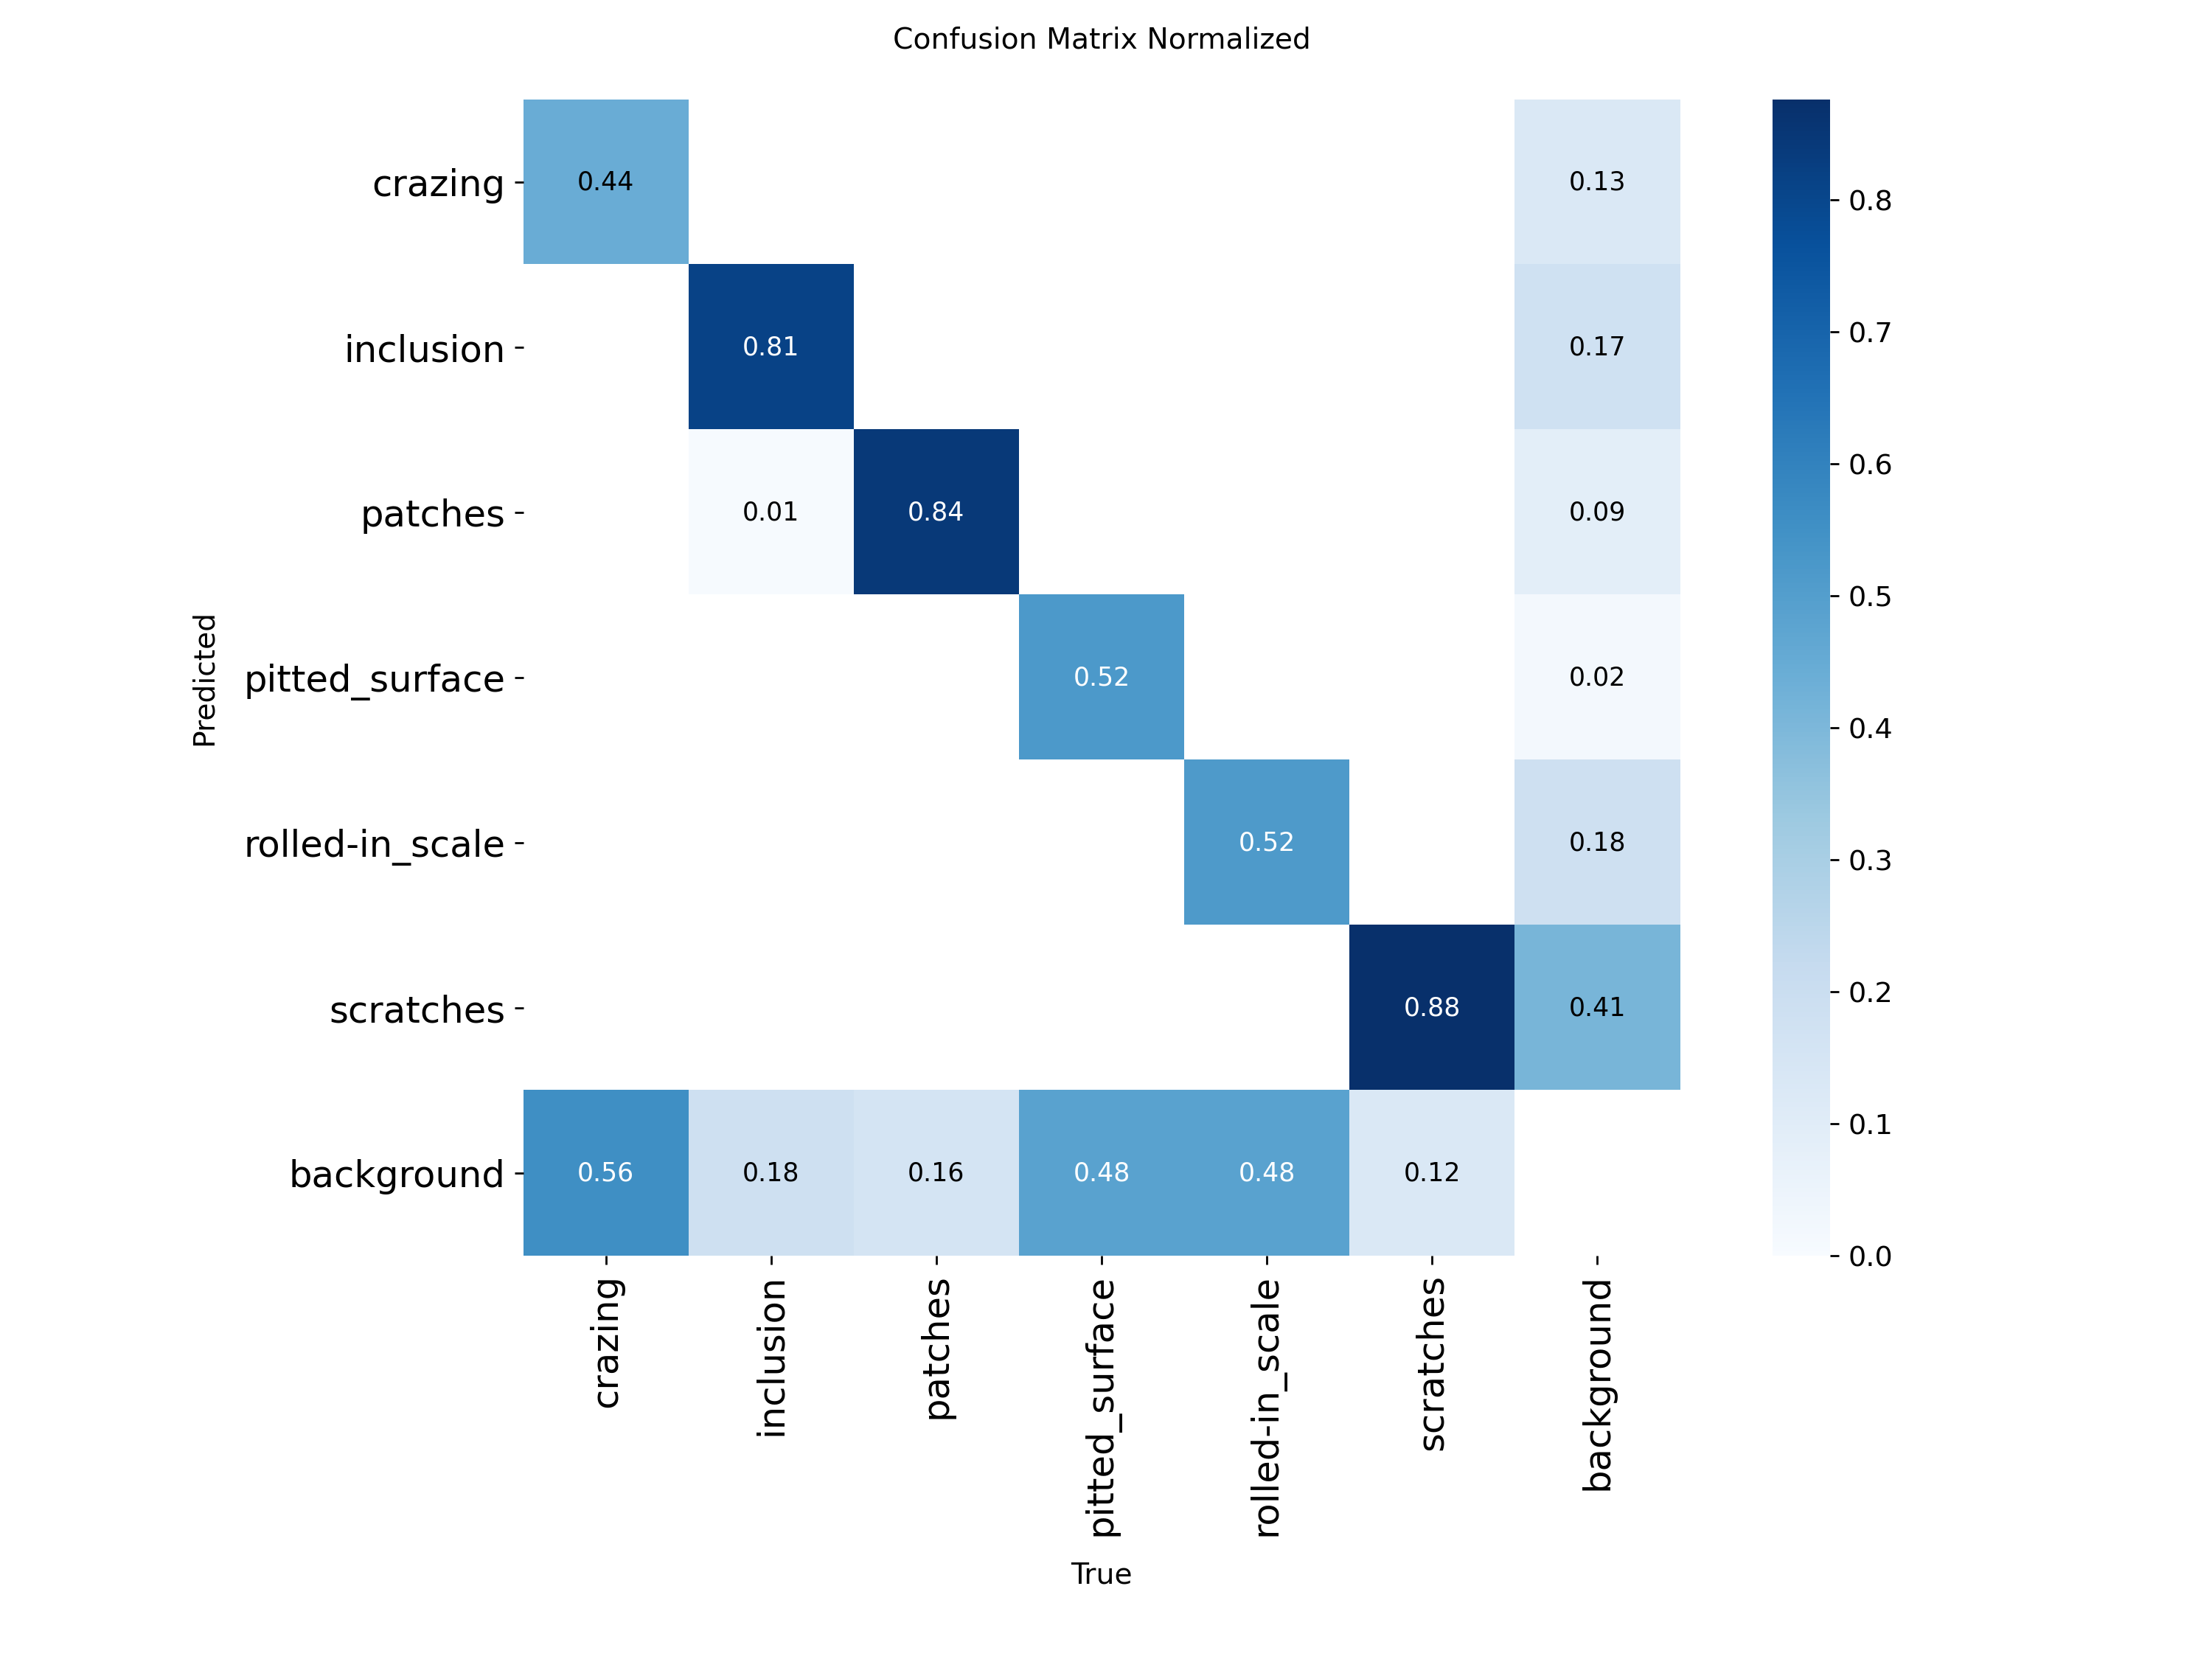

In [15]:
# ── Training curves ───────────────────────────────────────────
csv_path=str(yolo_results.save_dir)+'/results.csv'
if os.path.exists(csv_path):
    df_log=pd.read_csv(csv_path); df_log.columns=df_log.columns.str.strip()
    fig,axes=plt.subplots(2,3,figsize=(16,8))
    fig.suptitle('YOLOv8 Training Curves',fontsize=14,fontweight='bold')
    for ax,(col,title,color) in zip(axes.flatten(),[
        ('train/box_loss','Box Loss','darkorange'),('train/cls_loss','Class Loss','crimson'),
        ('train/dfl_loss','DFL Loss','purple'),('metrics/mAP50(B)','mAP@50','steelblue'),
        ('metrics/precision(B)','Precision','seagreen'),('metrics/recall(B)','Recall','teal')]):
        if col in df_log.columns:
            ax.plot(df_log['epoch'],df_log[col],color=color,linewidth=2)
            best=df_log[col].max() if 'metrics' in col else df_log[col].min()
            ax.axhline(best,linestyle='--',color=color,alpha=0.35,label=f'Best:{best:.4f}')
            ax.legend(fontsize=8)
        ax.set_title(title,fontweight='bold'); ax.set_xlabel('Epoch'); ax.grid(True,alpha=0.25)
    plt.tight_layout()
    plt.savefig(os.path.join(WORK_DIR,'yolo_training_curves.png'),dpi=130,bbox_inches='tight')
    plt.show()

# YOLO auto-generated plots (note: use display() not Image() to avoid PIL conflict)
from IPython.display import display
import IPython.display as IPyd
for fname in ['confusion_matrix_normalized.png','PR_curve.png','F1_curve.png']:
    fpath=os.path.join(str(yolo_results.save_dir),fname)
    if os.path.exists(fpath):
        print(f'\n📊 {fname}')
        display(IPyd.Image(fpath))

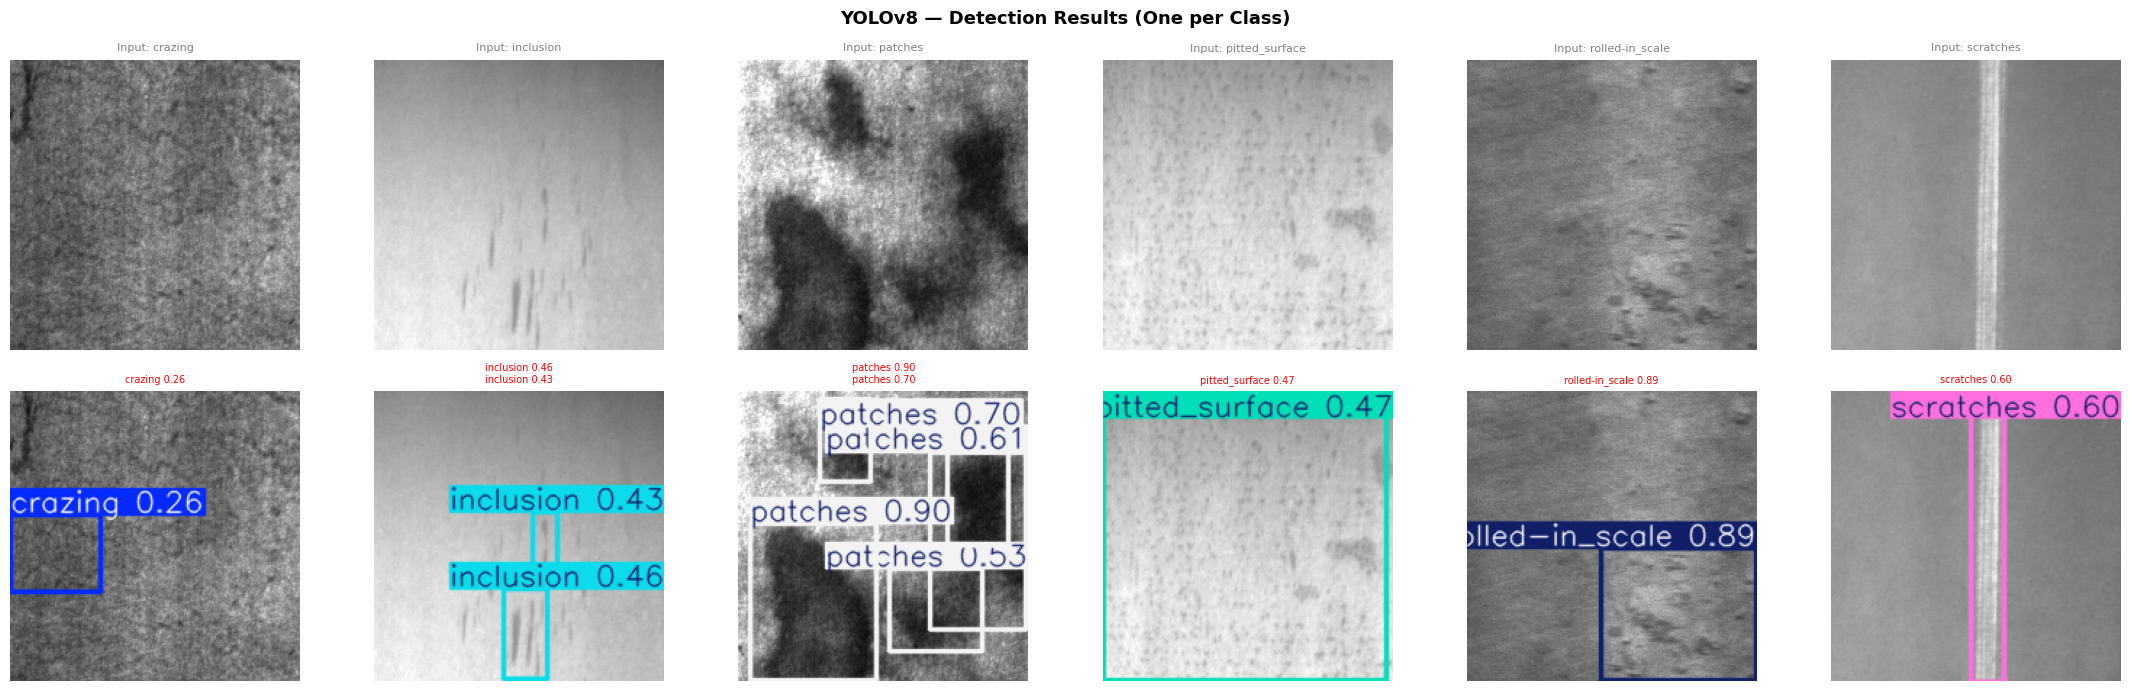

✅ Inference complete.


In [16]:
# ── YOLO Inference ────────────────────────────────────────────
import random
sample_imgs=[]
for cls in CLASSES:
    sub=df_test[df_test['label']==cls]
    if len(sub)==0: sub=df_val[df_val['label']==cls]
    sample_imgs.append(sub.iloc[0]['image_path'])

preds=best_yolo.predict(source=sample_imgs,conf=0.25,iou=0.45,imgsz=640,verbose=False)

fig,axes=plt.subplots(2,6,figsize=(22,7))
fig.suptitle('YOLOv8 — Detection Results (One per Class)',fontsize=13,fontweight='bold')
for i,(pred,ip,cls) in enumerate(zip(preds,sample_imgs,CLASSES)):
    orig=cv2.cvtColor(cv2.imread(ip),cv2.COLOR_BGR2RGB)
    pred_img=cv2.cvtColor(pred.plot(),cv2.COLOR_BGR2RGB)
    dets=[f'{CLASSES[int(b.cls)] if int(b.cls)<6 else "?"} {float(b.conf):.2f}' for b in (pred.boxes or [])]
    axes[0,i].imshow(orig,cmap='gray'); axes[0,i].set_title(f'Input: {cls}',fontsize=8,color='gray'); axes[0,i].axis('off')
    axes[1,i].imshow(pred_img)
    axes[1,i].set_title('\n'.join(dets[:2]) if dets else 'No det.',fontsize=7,color='red' if dets else 'gray')
    axes[1,i].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR,'yolo_inference.png'),dpi=130,bbox_inches='tight')
plt.show(); print('✅ Inference complete.')

---
## 🧠 MODULE B — ResNet50 + RandomForest

**Task:** *Classification only* (no bounding boxes)  
ResNet50 (frozen) extracts 2048-dim feature vectors → RandomForest classifies them.  
No training of ResNet50 — purely feature extraction via forward pass.

In [17]:
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader

resnet=models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet=torch.nn.Sequential(*list(resnet.children())[:-1])
resnet.eval()
DEVICE='cuda' if torch.cuda.is_available() else 'cpu'
resnet=resnet.to(DEVICE)

transform=T.Compose([T.ToPILImage(),T.Resize((224,224)),T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])])

class SteelDS(Dataset):
    def __init__(self,df,tr): self.df=df.reset_index(drop=True); self.tr=tr
    def __len__(self): return len(self.df)
    def __getitem__(self,idx):
        row=self.df.iloc[idx]
        img=cv2.imread(row['image_path'],cv2.IMREAD_GRAYSCALE)
        if img is None: img=np.zeros((200,200),dtype=np.uint8)
        return self.tr(cv2.cvtColor(img,cv2.COLOR_GRAY2RGB)), int(row['label_id'])

def extract_features(df,desc=''):
    ds=SteelDS(df,transform)
    loader=DataLoader(ds,batch_size=64,shuffle=False,num_workers=2,pin_memory=True)
    feats,labels=[],[]
    resnet.eval()
    with torch.no_grad():
        for imgs,lbs in loader:
            out=resnet(imgs.to(DEVICE)).squeeze(-1).squeeze(-1)
            feats.append(out.cpu().numpy()); labels.append(lbs.numpy())
    X=np.vstack(feats); y=np.hstack(labels)
    print(f'  {desc}: {X.shape}'); return X,y

print('🔍 Extracting ResNet50 features (frozen — no training)...')
X_train,y_train=extract_features(df_train_final,'Train')
X_val,y_val    =extract_features(df_val,        'Val  ')
X_test,y_test  =extract_features(df_test,       'Test ')
print(f'\n✅ Done! Each image → {X_train.shape[1]}-dim feature vector')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 160MB/s]


🔍 Extracting ResNet50 features (frozen — no training)...
  Train: (1372, 2048)
  Val  : (360, 2048)
  Test : (243, 2048)

✅ Done! Each image → 2048-dim feature vector


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,precision_score,recall_score,
                              f1_score,classification_report,confusion_matrix)

scaler=StandardScaler()
X_tr_sc=scaler.fit_transform(X_train)
X_vl_sc=scaler.transform(X_val)
X_ts_sc=scaler.transform(X_test)

print('🌲 Training RandomForest...')
t0=time.time()
rf=RandomForestClassifier(n_estimators=200,class_weight='balanced',
                           min_samples_leaf=2,random_state=42,n_jobs=-1)
rf.fit(X_tr_sc,y_train)
print(f'✅ Done in {time.time()-t0:.1f}s')

def eval_rf(X,y,name):
    p=rf.predict(X)
    return {'name':name,'preds':p,
            'acc':accuracy_score(y,p),'prec':precision_score(y,p,average='weighted',zero_division=0),
            'rec':recall_score(y,p,average='weighted',zero_division=0),
            'f1':f1_score(y,p,average='weighted',zero_division=0)}

rf_val =eval_rf(X_vl_sc,y_val, 'Validation')
rf_test=eval_rf(X_ts_sc,y_test,'Test')

rf_acc=rf_test['acc']; rf_prec=rf_test['prec']
rf_rec=rf_test['rec']; rf_f1=rf_test['f1']

print('\n'+'='*52)
print('   📊  RESNET50 + RANDOMFOREST RESULTS')
print('='*52)
for r in [rf_val,rf_test]:
    print(f"   {r['name']}:")
    print(f"     Accuracy  : {r['acc']*100:.1f}%")
    print(f"     Precision : {r['prec']*100:.1f}%")
    print(f"     Recall    : {r['rec']*100:.1f}%")
    print(f"     F1-Score  : {r['f1']*100:.1f}%\n")
print('='*52)
print('\nClassification Report (Test):')
print(classification_report(y_test,rf_test['preds'],target_names=CLASSES,zero_division=0))

🌲 Training RandomForest...
✅ Done in 7.4s

   📊  RESNET50 + RANDOMFOREST RESULTS
   Validation:
     Accuracy  : 96.9%
     Precision : 97.3%
     Recall    : 96.9%
     F1-Score  : 96.9%

   Test:
     Accuracy  : 97.1%
     Precision : 97.2%
     Recall    : 97.1%
     F1-Score  : 97.1%


Classification Report (Test):
                 precision    recall  f1-score   support

        crazing       1.00      0.94      0.97        36
      inclusion       0.97      0.92      0.95        38
        patches       0.96      1.00      0.98        44
 pitted_surface       0.96      0.98      0.97        54
rolled-in_scale       1.00      1.00      1.00        36
      scratches       0.94      0.97      0.96        35

       accuracy                           0.97       243
      macro avg       0.97      0.97      0.97       243
   weighted avg       0.97      0.97      0.97       243



🔥 Fine-tuning ResNet50 for Grad-CAM (10 epochs)...
  Epoch  1 | Loss: 0.3822 | Train: 91.0% | Val: 98.6%
  Epoch  2 | Loss: 0.0882 | Train: 97.7% | Val: 97.2%
  Epoch  3 | Loss: 0.0534 | Train: 98.3% | Val: 99.2%
  Epoch  4 | Loss: 0.0308 | Train: 99.2% | Val: 99.2%
  Epoch  5 | Loss: 0.0255 | Train: 99.3% | Val: 98.9%
  Epoch  6 | Loss: 0.0168 | Train: 99.6% | Val: 98.6%
  Epoch  7 | Loss: 0.0118 | Train: 99.7% | Val: 98.6%
  Epoch  8 | Loss: 0.0148 | Train: 99.6% | Val: 98.9%
  Epoch  9 | Loss: 0.0098 | Train: 99.9% | Val: 98.9%
  Epoch 10 | Loss: 0.0078 | Train: 99.9% | Val: 98.9%

✅ Best Val Accuracy: 99.2%


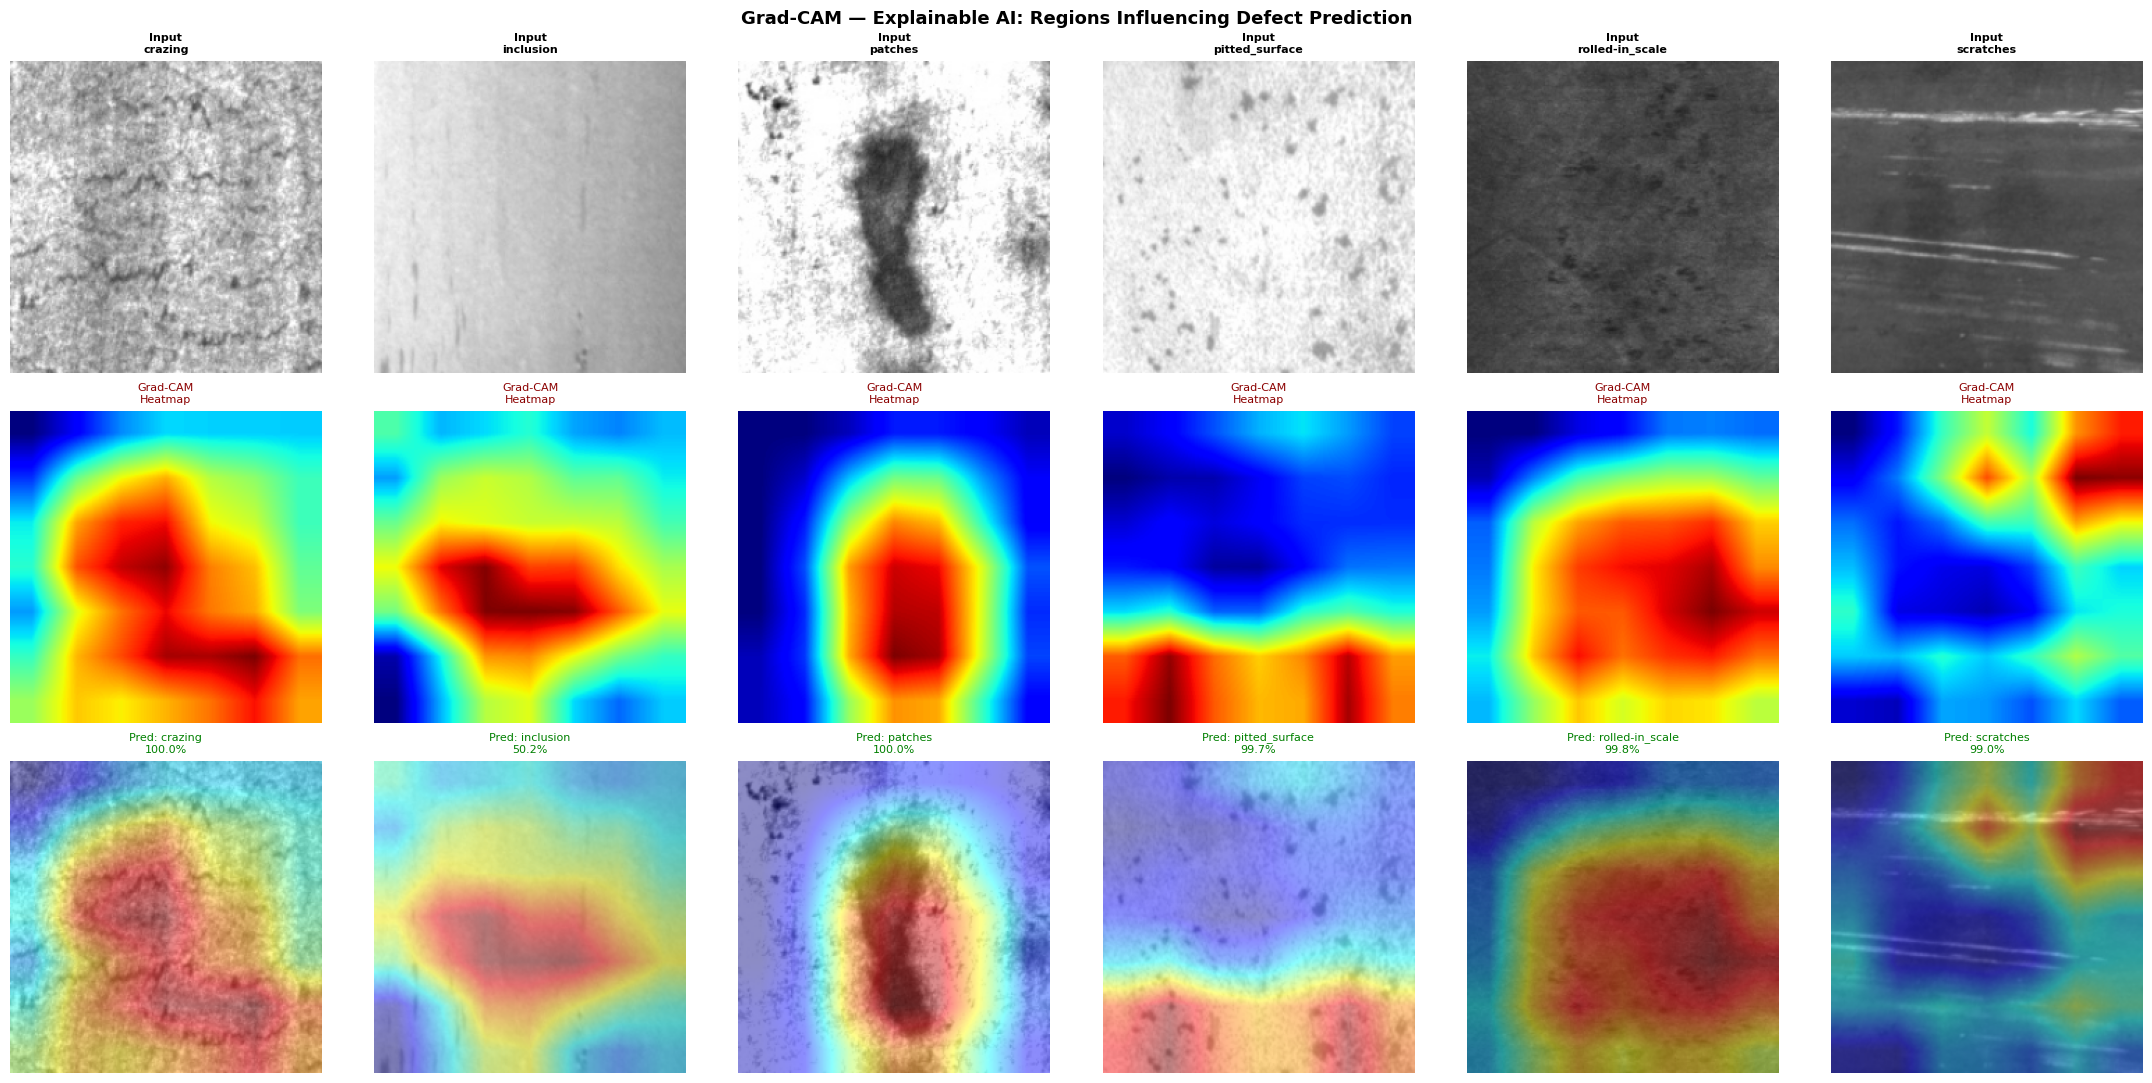

✅ Grad-CAM visualization complete!


In [19]:

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
import cv2, numpy as np, matplotlib.pyplot as plt, os

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── Fine-tunable ResNet50 (adds classification head) ─────────
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.features = nn.Sequential(*list(base.children())[:-2])
        self.avgpool  = nn.AdaptiveAvgPool2d((1,1))
        self.fc       = nn.Linear(2048, num_classes)
        for p in self.features[:-1].parameters():
            p.requires_grad = False   # freeze all but layer4

    def forward(self, x):
        f = self.features(x)
        out = self.avgpool(f)
        out = torch.flatten(out, 1)
        return self.fc(out), f

clf_model = ResNet50Classifier(num_classes=6).to(DEVICE)

# ── Fine-tune 10 epochs ──────────────────────────────────────
from torch.utils.data import Dataset, DataLoader

transform_tr = T.Compose([
    T.ToPILImage(), T.Resize((224,224)), T.RandomHorizontalFlip(),
    T.ColorJitter(0.2,0.2), T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
transform_vl = T.Compose([
    T.ToPILImage(), T.Resize((224,224)), T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

class SteelDS(Dataset):
    def __init__(self, df, tr):
        self.df = df.reset_index(drop=True); self.tr = tr
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row['image_path'], cv2.IMREAD_GRAYSCALE)
        if img is None: img = np.zeros((200,200), dtype=np.uint8)
        return self.tr(cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)), int(row['label_id'])

train_loader = DataLoader(SteelDS(df_train_final, transform_tr),
                          batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(SteelDS(df_val,         transform_vl),
                          batch_size=32, shuffle=False, num_workers=2)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, clf_model.parameters()), lr=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

print('🔥 Fine-tuning ResNet50 for Grad-CAM (10 epochs)...')
best_val_acc = 0
for epoch in range(10):
    clf_model.train()
    running_loss = correct = total = 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        logits, _ = clf_model(imgs)
        loss = criterion(logits, lbls)
        loss.backward(); optimizer.step()
        running_loss += loss.item()
        correct += (logits.argmax(1) == lbls).sum().item(); total += len(lbls)
    scheduler.step()

    clf_model.eval(); vc = vt = 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            logits, _ = clf_model(imgs)
            vc += (logits.argmax(1) == lbls).sum().item(); vt += len(lbls)
    val_acc = vc/vt
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(clf_model.state_dict(), '/content/work/resnet50_finetuned.pth')
    print(f'  Epoch {epoch+1:2d} | Loss: {running_loss/len(train_loader):.4f} '
          f'| Train: {correct/total*100:.1f}% | Val: {val_acc*100:.1f}%')

print(f'\n✅ Best Val Accuracy: {best_val_acc*100:.1f}%')
clf_model.load_state_dict(torch.load('/content/work/resnet50_finetuned.pth'))
clf_model.eval()

# ── Grad-CAM class ───────────────────────────────────────────
class GradCAM:
    def __init__(self, model):
        self.model = model
        self.activations = self.gradients = None
        model.features[-1][-1].register_forward_hook(
            lambda m,i,o: setattr(self,'activations',o.detach()))
        model.features[-1][-1].register_full_backward_hook(
            lambda m,gi,go: setattr(self,'gradients',go[0].detach()))

    def generate(self, tensor, class_idx=None):
        self.model.zero_grad()
        logits, _ = self.model(tensor)
        if class_idx is None: class_idx = logits.argmax(1).item()
        logits[0, class_idx].backward()
        w   = self.gradients.mean(dim=[2,3], keepdim=True)
        cam = torch.relu((w * self.activations).sum(1)).squeeze().cpu().numpy()
        cam = cv2.resize(cam, (224,224))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        conf = float(torch.softmax(logits, dim=1)[0, class_idx])
        return cam, class_idx, conf

gradcam = GradCAM(clf_model)

transform_infer = T.Compose([
    T.ToPILImage(), T.Resize((224,224)), T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# ── Visualise one per class ──────────────────────────────────
fig, axes = plt.subplots(3, 6, figsize=(22,11))
fig.suptitle('Grad-CAM — Explainable AI: Regions Influencing Defect Prediction',
             fontsize=13, fontweight='bold')

for ci, cls in enumerate(CLASSES):
    row = df_val[df_val['label']==cls].iloc[0]
    img_gray = cv2.imread(row['image_path'], cv2.IMREAD_GRAYSCALE)
    if img_gray is None: img_gray = np.zeros((200,200), dtype=np.uint8)
    img_rgb     = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)
    img_resized = cv2.resize(img_rgb, (224,224))

    tensor = transform_infer(img_rgb).unsqueeze(0).to(DEVICE)
    cam, pred_idx, conf = gradcam.generate(tensor)

    heatmap = cv2.cvtColor(
        cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_resized, 0.55, heatmap, 0.45, 0)

    axes[0,ci].imshow(img_resized, cmap='gray')
    axes[0,ci].set_title(f'Input\n{cls}', fontsize=8, fontweight='bold')
    axes[0,ci].axis('off')

    axes[1,ci].imshow(cam, cmap='jet')
    axes[1,ci].set_title('Grad-CAM\nHeatmap', fontsize=8, color='darkred')
    axes[1,ci].axis('off')

    axes[2,ci].imshow(overlay)
    color = 'green' if pred_idx == ci else 'red'
    axes[2,ci].set_title(f'Pred: {CLASSES[pred_idx]}\n{conf*100:.1f}%',
                         fontsize=8, color=color)
    axes[2,ci].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR,'gradcam_visualization.png'), dpi=130, bbox_inches='tight')
plt.show()
print('✅ Grad-CAM visualization complete!')


In [20]:
import pickle, shutil, os

SAVE_DIR = '/content/drive/MyDrive/steel_defect_models'
os.makedirs(SAVE_DIR, exist_ok=True)

# 1 — YOLOv8 weights
shutil.copy2(BEST_PT, os.path.join(SAVE_DIR, 'yolov8_best.pt'))
print('✅ YOLOv8 best.pt saved')

# 2 — ResNet50 fine-tuned weights (for Grad-CAM)
shutil.copy2('/content/work/resnet50_finetuned.pth',
             os.path.join(SAVE_DIR, 'resnet50_finetuned.pth'))
print('✅ ResNet50 weights saved')

# 3 — RandomForest + Scaler
with open(os.path.join(SAVE_DIR, 'rf_model.pkl'), 'wb') as f:
    pickle.dump({'rf': rf, 'scaler': scaler}, f)
print('✅ RF model + scaler saved')

# 4 — CSVs for dashboard demo
df_val.to_csv(os.path.join(SAVE_DIR, 'val_images.csv'),  index=False)
df_test.to_csv(os.path.join(SAVE_DIR, 'test_images.csv'), index=False)
print('✅ Dataset CSVs saved')

print(f'\n📁 Everything saved to: {SAVE_DIR}')
print('   Download to local machine, place next to app.py, then run:')
print('   streamlit run app.py')

✅ YOLOv8 best.pt saved
✅ ResNet50 weights saved
✅ RF model + scaler saved
✅ Dataset CSVs saved

📁 Everything saved to: /content/drive/MyDrive/steel_defect_models
   Download to local machine, place next to app.py, then run:
   streamlit run app.py


---
## 📊 MODEL COMPARISON

### ⚠️ Important: Why YOLO mAP < RF Accuracy is EXPECTED

| | YOLOv8 (Detection) | ResNet50+RF (Classification) |
|---|---|---|
| **Task** | Detect + Locate defects | Classify whole image |
| **Metric** | mAP@50 (box overlap required) | Accuracy (label match only) |
| **Penalized for** | Wrong box position, wrong class | Wrong class only |
| **Gives bounding box** | ✅ Yes | ❌ No |
| **Industrial use** | Find WHERE defect is on steel sheet | Quick pass/fail decision |

**mAP@50 is a harder metric** — the model must BOTH classify correctly AND place the bounding box correctly (≥50% overlap). RF only needs to get the class right. Comparing them directly is like comparing exam scores where one student must show all working and the other can just circle the answer.

   FINAL MODEL COMPARISON
   Metric                YOLOv8s (Detection) ResNet50+RF (Classif.)
--------------------------------------------------------------------
   Task                    Detect + Localize          Classify only
   Metric type               mAP@50 (harder)      Accuracy (easier)
   mAP@50                              72.1%                     N/A
   Accuracy                              N/A                  97.1%
   Precision                           65.9%                   97.2%
   Recall                              71.4%                   97.1%
   F1-Score                            68.6%                   97.1%
--------------------------------------------------------------------
   Bounding Box       ✅ Yes — exact location                   ❌ No
   Real-time                       ✅ 30+ FPS                 ✅ Fast
   Needs training               ✅ Fine-tuned          ❌ No training
   Best for               Production line QC        Quick screening



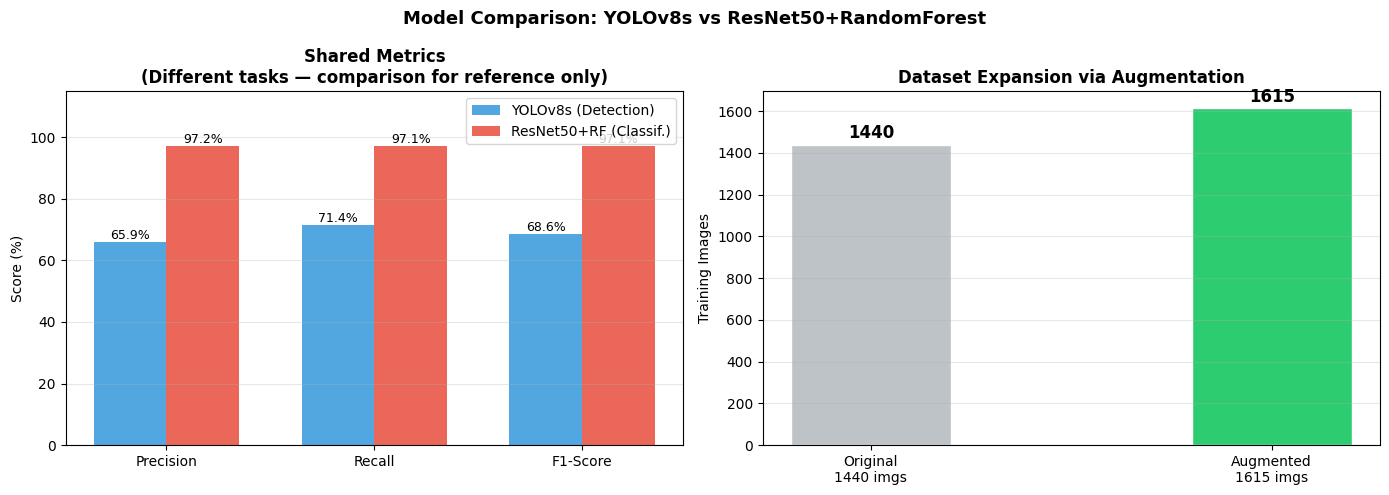

In [21]:
print('='*68)
print('   FINAL MODEL COMPARISON')
print('='*68)
print(f"   {'Metric':<18} {'YOLOv8s (Detection)':>22} {'ResNet50+RF (Classif.)':>22}")
print('-'*68)
print(f"   {'Task':<18} {'Detect + Localize':>22} {'Classify only':>22}")
print(f"   {'Metric type':<18} {'mAP@50 (harder)':>22} {'Accuracy (easier)':>22}")
print(f"   {'mAP@50':<18} {yolo_map50*100:>21.1f}%  {'N/A':>22}")
print(f"   {'Accuracy':<18} {'N/A':>22} {rf_acc*100:>21.1f}%")
print(f"   {'Precision':<18} {yolo_prec*100:>21.1f}%  {rf_prec*100:>21.1f}%")
print(f"   {'Recall':<18} {yolo_recall*100:>21.1f}%  {rf_rec*100:>21.1f}%")
print(f"   {'F1-Score':<18} {yolo_f1*100:>21.1f}%  {rf_f1*100:>21.1f}%")
print('-'*68)
print(f"   {'Bounding Box':<18} {'✅ Yes — exact location':>22} {'❌ No':>22}")
print(f"   {'Real-time':<18} {'✅ 30+ FPS':>22} {'✅ Fast':>22}")
print(f"   {'Needs training':<18} {'✅ Fine-tuned':>22} {'❌ No training':>22}")
print(f"   {'Best for':<18} {'Production line QC':>22} {'Quick screening':>22}")
print('='*68)
print()


# Visual comparison
fig,axes=plt.subplots(1,2,figsize=(14,5))
fig.suptitle('Model Comparison: YOLOv8s vs ResNet50+RandomForest',fontsize=13,fontweight='bold')

# Shared metrics bar chart
metrics=['Precision','Recall','F1-Score']
yolo_s=[yolo_prec*100,yolo_recall*100,yolo_f1*100]
rf_s  =[rf_prec*100,  rf_rec*100,     rf_f1*100]
x=np.arange(len(metrics)); w=0.35
b1=axes[0].bar(x-w/2,yolo_s,w,label='YOLOv8s (Detection)',color='#3498DB',alpha=0.85)
b2=axes[0].bar(x+w/2,rf_s,  w,label='ResNet50+RF (Classif.)',color='#E74C3C',alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics,fontsize=10)
axes[0].set_ylabel('Score (%)'); axes[0].set_ylim(0,115)
axes[0].set_title('Shared Metrics\n(Different tasks — comparison for reference only)',fontweight='bold')
axes[0].legend(); axes[0].grid(axis='y',alpha=0.3)
for b in list(b1)+list(b2):
    axes[0].text(b.get_x()+b.get_width()/2,b.get_height()+1,f'{b.get_height():.1f}%',ha='center',fontsize=9)

# Augmentation impact
axes[1].bar(['Original\n1440 imgs',f'Augmented\n{len(df_train_all)} imgs'],
            [1440,len(df_train_all)],color=['#BDC3C7','#2ECC71'],edgecolor='white',width=0.4)
axes[1].set_title('Dataset Expansion via Augmentation',fontweight='bold')
axes[1].set_ylabel('Training Images')
for i,v in enumerate([1440,len(df_train_all)]):
    axes[1].text(i,v+30,str(v),ha='center',fontweight='bold',fontsize=12)
axes[1].grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR,'model_comparison.png'),dpi=130,bbox_inches='tight')
plt.show()

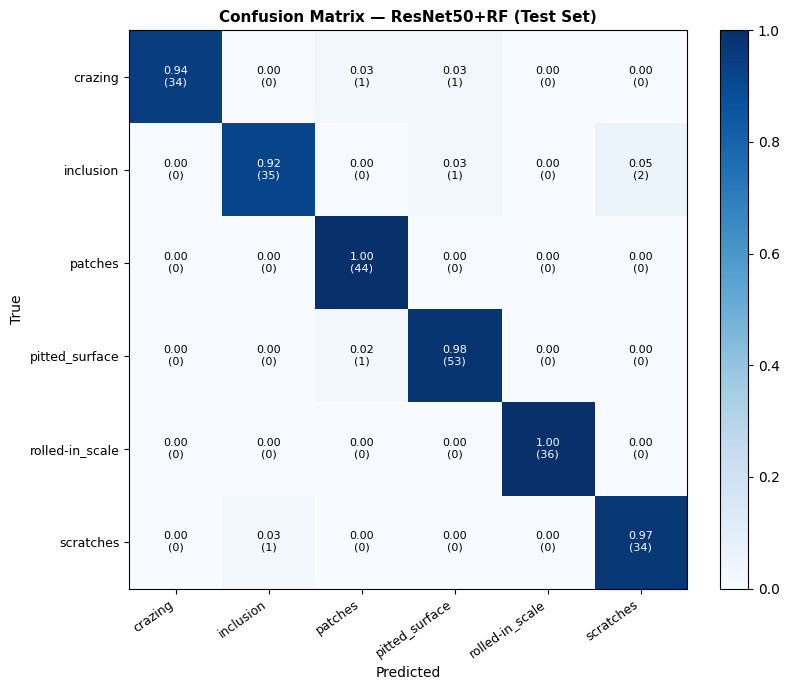

✅ Confusion matrix saved.


In [22]:
# ── Confusion matrix ──────────────────────────────────────────
cm=confusion_matrix(y_test,rf_test['preds'])
cm_norm=cm.astype(float)/cm.sum(axis=1,keepdims=True)
fig,ax=plt.subplots(figsize=(9,7))
im=ax.imshow(cm_norm,cmap='Blues',vmin=0,vmax=1)
plt.colorbar(im,ax=ax,fraction=0.046,pad=0.04)
ax.set_xticks(range(6)); ax.set_yticks(range(6))
ax.set_xticklabels(CLASSES,rotation=35,ha='right',fontsize=9)
ax.set_yticklabels(CLASSES,fontsize=9)
ax.set_title('Confusion Matrix — ResNet50+RF (Test Set)',fontweight='bold',fontsize=11)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
for i,j in itertools.product(range(6),range(6)):
    ax.text(j,i,f'{cm_norm[i,j]:.2f}\n({cm[i,j]})',ha='center',va='center',
            fontsize=8,color='white' if cm_norm[i,j]>0.5 else 'black')
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR,'confusion_matrix.png'),dpi=130,bbox_inches='tight')
plt.show(); print('✅ Confusion matrix saved.')